In [35]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy.stats import linregress
from itertools import combinations
import numpy as np
from sklearn.linear_model import LinearRegression
from itertools import combinations
import math 

In [ ]:
# this is the first genome informed model that was worked on for modeled od600 with only th einclusion of carbon sources


df = pd.read_csv('/Users/juar705/dashboard/bacterAI_dash/P_putida_AG5577_baseline/Round1/mapped_data_2025-04-15_biotek_final_od_data.csv')
ingredient_columns = ['d_glucose', 'sodium_acetate', 'sodium_citrate', 'sodium_octanoate', 'sodium_benzoate']
growth_column = 'y'
df = df.dropna(subset=ingredient_columns + [growth_column]).reset_index(drop=True)
od600 = df['y'].values

conversion_factors = {
    "glucose": 0.5,
    "sodium_octanoate": 0.8,
    "sodium_benzoate": 0.25,
    "sodium_citrate": 0.38,
    "sodium_acetate": 0.27,
}
# mmol/gDW/hr
uptake_rates = {
    "glucose": 4.0,
    "sodium_octanoate": 3.0,
    "sodium_benzoate": 3.45,
    "sodium_citrate": 4.0,
    "sodium_acetate": 12.0,
}
# yield coefficients are actually Biomass growth rate to convert to coefficeint it has to be divided by the uptake rate
yield_coefficients = {
    "glucose": 0.39,
    "sodium_octanoate": 1.08,
    "sodium_benzoate": 0.896,
    "sodium_citrate": 0.898,
    "sodium_acetate": 0.699,
}

#  mmol/L
substrate_concentrations = {
    "glucose": df["d_glucose"].values,
    "sodium_acetate": df["sodium_acetate"].values,
    "sodium_citrate": df["sodium_citrate"].values,
    "sodium_octanoate": df["sodium_octanoate"].values,
    "sodium_benzoate": df["sodium_benzoate"].values,
    "sodium_chloride": df["sodium_chloride"].values,
    "potassium_chloride": df["potassium_chloride"].values,
}

carbon_sources = ['glucose', 'sodium_octanoate', 'sodium_benzoate', 'sodium_citrate', 'sodium_acetate']
salts = ['sodium_chloride', 'potassium_chloride']
salt_concentrations = {
    "sodium_chloride": df["sodium_chloride"].values,
    "potassium_chloride": df["potassium_chloride"].values,
}
salt_IC50 = {
    "sodium_chloride": 1.80,  # Example value, replace with actual IC50
    "potassium_chloride": 1.43,  # Example value, replace with actual IC50
}
pH  = df['pH'].values

In [37]:
def compute_modeled_od600(df, carbon_sources, conversion_factors, uptake_rates, yield_coefficients, combinations, substrate_concentrations):
    """
    Compute modeled OD600 for each carbon source in the dataframe using substrate concentrations.
    Adds a new column for each modeled OD600.
    Also computes and prints the regression slope/intercept between OD600 and biomass for each source.
    """
    cdw_dict = {}
    biomass_dict = {}
    regression_results = {}

    for source in carbon_sources:
        substrate_conc = substrate_concentrations[source]
        conversion_factor = conversion_factors[source]
        uptake_rate = uptake_rates[source]
        yield_coefficient = yield_coefficients[source]
        
        # Calculate biomass produced from substrate
        biomass = substrate_conc * (yield_coefficient / uptake_rate)
        #for loop for as many hours it will run for 48 hrs
        od600cdw = od600 * conversion_factor  # Convert OD600 to CDW (g/L)for slope and intercept calulation in same units
        #get slopes of od 600 and biomass using regression
        slope, intercept = linregress(biomass, od600cdw)[:2]
        regression_results[source] = {'slope': slope, 'intercept': intercept}
        print(f"{source}: slope={slope:.4f}, intercept={intercept:.4f}")
        
        # convert biomass to OD600
        modeled_od600 = slope * biomass + intercept 
        df[f'modeled_od600_{source}'] = modeled_od600
        cdw_dict[source] = substrate_conc * conversion_factor
        biomass_dict[source] = biomass
    
    for combo in all_combinations:
        combo_name = '+'.join(combo)
        modeled_ods = np.stack([df[f'modeled_od600_{s}'] for s in combo], axis=1)  # shape: (n_samples, n_combo)
        # taking a sum logic as all sources will be contributing to the OD600
        df[f'modeled_od600_{combo_name}_sum'] = np.sum(modeled_ods, axis=1)  

    return df

all_combinations = []
for r in range(2, len(carbon_sources) + 1):
    all_combinations.extend(combinations(carbon_sources, r))
for combo in all_combinations:
    print(combo)

df = compute_modeled_od600(df, carbon_sources, conversion_factors, uptake_rates, yield_coefficients, all_combinations, substrate_concentrations)

output_columns = (
    ['y'] +
    [f'modeled_od600_{s}' for s in carbon_sources] +
    [f'modeled_od600_{"+".join(combo)}_sum' for combo in all_combinations]
)
df_modeled = df[output_columns]
print(df_modeled)


('glucose', 'sodium_octanoate')
('glucose', 'sodium_benzoate')
('glucose', 'sodium_citrate')
('glucose', 'sodium_acetate')
('sodium_octanoate', 'sodium_benzoate')
('sodium_octanoate', 'sodium_citrate')
('sodium_octanoate', 'sodium_acetate')
('sodium_benzoate', 'sodium_citrate')
('sodium_benzoate', 'sodium_acetate')
('sodium_citrate', 'sodium_acetate')
('glucose', 'sodium_octanoate', 'sodium_benzoate')
('glucose', 'sodium_octanoate', 'sodium_citrate')
('glucose', 'sodium_octanoate', 'sodium_acetate')
('glucose', 'sodium_benzoate', 'sodium_citrate')
('glucose', 'sodium_benzoate', 'sodium_acetate')
('glucose', 'sodium_citrate', 'sodium_acetate')
('sodium_octanoate', 'sodium_benzoate', 'sodium_citrate')
('sodium_octanoate', 'sodium_benzoate', 'sodium_acetate')
('sodium_octanoate', 'sodium_citrate', 'sodium_acetate')
('sodium_benzoate', 'sodium_citrate', 'sodium_acetate')
('glucose', 'sodium_octanoate', 'sodium_benzoate', 'sodium_citrate')
('glucose', 'sodium_octanoate', 'sodium_benzoate', 

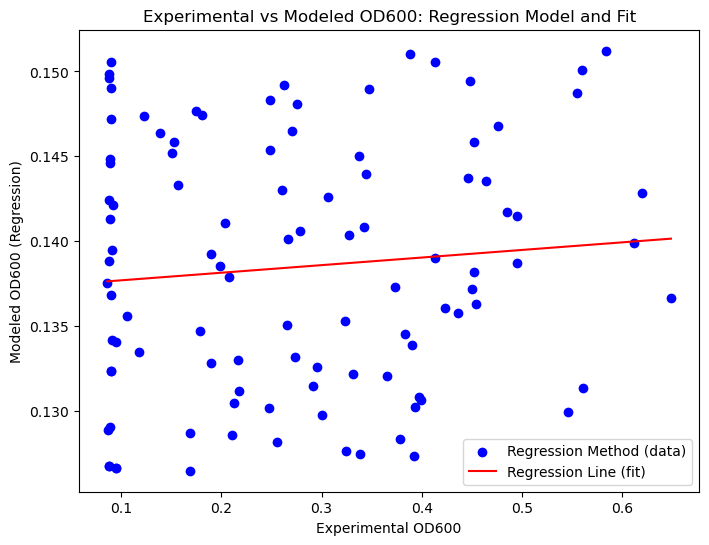

In [38]:
#regression fit modeled per ingredient
x = df['y']
y = df['modeled_od600_glucose']
slope, intercept = linregress(x, y)[:2]
x_fit = np.linspace(x.min(), x.max(), 103)
y_fit = slope * x_fit + intercept

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Regression Method (data)')
plt.plot(x_fit, y_fit, color='red', label='Regression Line (fit)')
plt.xlabel("Experimental OD600")
plt.ylabel("Modeled OD600 (Regression)")
plt.title("Experimental vs Modeled OD600: Regression Model and Fit")
plt.legend()
plt.show()

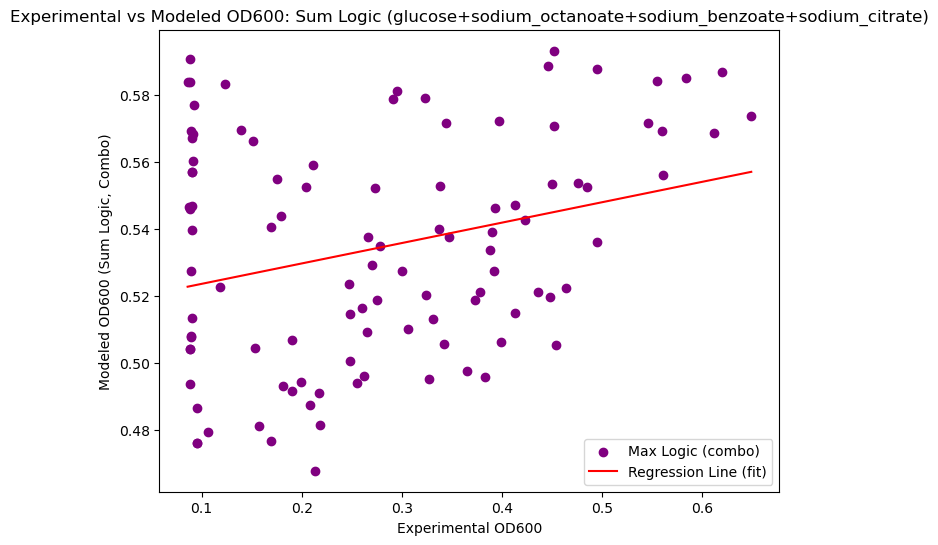

In [39]:
combo_name = 'glucose+sodium_octanoate+sodium_benzoate+sodium_citrate'
x = df['y']
y = df[f'modeled_od600_{combo_name}_sum']  # Using sum logic for the combo

from scipy.stats import linregress
slope, intercept = linregress(x, y)[:2]
x_fit = np.linspace(x.min(), x.max(), 103)
y_fit = slope * x_fit + intercept

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='purple', label='Max Logic (combo)')
plt.plot(x_fit, y_fit, color='red', label='Regression Line (fit)')
plt.xlabel("Experimental OD600")
plt.ylabel("Modeled OD600 (Sum Logic, Combo)")
plt.title(f"Experimental vs Modeled OD600: Sum Logic ({combo_name})")
plt.legend()
plt.show()